# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Wahyu
- **Email:** go.wahyu28@gmail.com
- **ID Dicoding:** binara

## Menentukan Pertanyaan Bisnis

Pertanyaan 1:

Negara bagian (state) dan kota mana yang memiliki basis pelanggan terbanyak, sehingga kita dapat memfokuskan 50% alokasi anggaran pemasaran lokal di wilayah tersebut pada kuartal mendatang?

Keterangan:

- **Specific**: Lokasi pelanggan.
- **Measurable**: Jumlah terbanyak.
- **Action-Oriented**: Alokasi budget.
- **Relevant**: Efisiensi marketing.
- **Time-bound**: Kuartal mendatang.

Pertanyaan 2:

Bagaimana proporsi produk di dalam katalog jika dikelompokkan berdasarkan kategori beratnya (Ringan <1kg, Sedang 1-5kg, Berat >5kg), dan kelompok mana yang paling dominan untuk bahan negosiasi tarif flat dengan mitra logistik pengiriman tahun ini?

Keterangan:

- **Specific**: Kategori berat produk.
- **Measurable**: Proporsi atau Persentase kelompok.
- **Action-Oriented**: Negosiasi tarif logistik.
- **Relevant**: Menekan biaya operasional pengiriman.
- **Time-bound**: Tahun ini.

## Import Semua Packages/Library yang Digunakan

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [75]:
# Tabel Customer

customers_df = pd.read_csv("data/customers_dataset.csv")
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [76]:
# Tabel Product

products_df = pd.read_csv("data/products_dataset.csv")
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


**Insight:**
- Tabel `customers_df` memiliki 99.441 baris data dan 5 kolom. Tabel ini memuat informasi demografi geografis pelanggan seperti ID unik, kode pos, kota, dan negara bagian (state).


- Tabel `products_df` memiliki 32.951 baris data dan 9 kolom. Tabel ini memuat karakteristik fisik dari produk yang dijual, seperti nama kategori, berat (gram), panjang, tinggi, dan lebar produk.

### Assessing Data

In [77]:
# MENILAI DATA customers_df

# periksa tipe data
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [78]:
# periksa missing value

print("Missing value di Customers:\n", customers_df.isnull().sum())

Missing value di Customers:
 customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


In [79]:
# periksa duplikasi

print("\nDuplikasi di Customers:", customers_df.duplicated().sum())


Duplikasi di Customers: 0


In [80]:
# MENILAI DATA products_df

# periksa tipe data
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [81]:
# periksa missing value

print("\nMissing value di Products:\n", products_df.isnull().sum())


Missing value di Products:
 product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


In [82]:
# periksa duplikasi

print("Duplikasi di Products:", products_df.duplicated().sum())

Duplikasi di Products: 0


**Insight:**
- Pada tabel `customers_df`, tidak ditemukan *missing value* maupun data duplikat. Kualitas data pelanggan sudah sangat baik.
- Pada tabel `products_df`, ditemukan *missing value* pada beberapa kolom, di antaranya `product_category_name` (610 baris), `product_weight_g` (2 baris), serta beberapa kolom dimensi produk lainnya. Tidak ditemukan duplikasi data.

- Tindakan Lanjutan: Tahap Cleaning Data perlu dilakukan pada tabel produk dengan melakukan imputasi (pengisian nilai) untuk menangani *missing value* tersebut agar tidak mengganggu proses analisis.

### Cleaning Data

In [83]:
# CLEANING DATA PADA products_df

# Mengatasi missing value pada kategori produk dengan string "unknown"
products_df['product_category_name'] = products_df['product_category_name'].fillna('unknown')

In [84]:
# Mengatasi missing value pada berat produk dengan nilai median
products_df['product_weight_g'] = products_df['product_weight_g'].fillna(products_df['product_weight_g'].median())

In [85]:
# Memastikan data sudah bersih
print(products_df.isnull().sum())

product_id                      0
product_category_name           0
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                0
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


In [86]:
# membersihkan kolom lain yang masih memiliki missing value

# kolom kolom yang masih memiliki missing value
kolom_product = [
    'product_name_lenght',
    'product_description_lenght',
    'product_photos_qty',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

# mengisi missing value pada kolom-kolom tersebut dengan nilai median
for kolom in kolom_product:
    products_df[kolom] = products_df[kolom].fillna(products_df[kolom].median())

# mengecek kembali untuk memastikan semua sudah bersih
print("Jumlah Missing Value Setelah Cleaning Menyeluruh:", products_df.isnull().sum())

Jumlah Missing Value Setelah Cleaning Menyeluruh: product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64


**Insight:**
- Missing value pada kolom kategorikal (`product_category_name`) telah berhasil ditangani dengan mengisi label `"unknown"`.
- Missing value pada kolom numerik (seperti `product_weight_g`, panjang, lebar, dll) telah diisi menggunakan nilai tengah (median) dari masing-masing kolom. Pemilihan median dilakukan karena lebih kebal terhadap data pencilan (*outlier*).


- Pengecekan ulang dilakukan dan menunjukkan angka 0 untuk seluruh kolom, yang berarti dataset sudah 100% bersih dan siap untuk dieksplorasi.

## Exploratory Data Analysis (EDA)

In [87]:
# EDA untuk Pertanyaan 1 mengenai persebaran geografis pelanggan

# Mengelompokkan pelanggan berdasarkan State (Negara Bagian)
bystate_df = customers_df.groupby(by="customer_state").customer_id.nunique().reset_index()
bystate_df.rename(columns={"customer_id": "customer_count"}, inplace=True)
bystate_df = bystate_df.sort_values(by="customer_count", ascending=False)
display(bystate_df.head())

,customer_state,customer_count
25,SP,41746
18,RJ,12852
10,MG,11635
22,RS,5466
17,PR,5045


In [88]:
# EDA untuk pertanyaan 2 mengenai berat produk

# Membuat kategori(binning) berat produk
bins = [0, 1000, 5000, np.inf]
labels = ['Ringan (<1kg)', 'Sedang (1-5kg)', 'Berat (>5kg)']

# Membuat kolom baru "weight_category"
products_df['weight_category'] = pd.cut(products_df['product_weight_g'], bins=bins, labels=labels)

# Melihat distribusi kelompok
weight_dist_df = products_df.groupby(by="weight_category", observed=True).product_id.nunique().reset_index()
weight_dist_df.rename(columns={"product_id": "product_count"}, inplace=True)
display(weight_dist_df)

,weight_category,product_count
0,Ringan (<1kg),20055
1,Sedang (1-5kg),8739
2,Berat (>5kg),4153


**Insight:**
- **Eksplorasi Pelanggan:** Negara bagian SP (São Paulo) adalah wilayah dengan basis pelanggan tertinggi, menembus angka lebih dari 40.000 pelanggan. Jumlah ini terpaut sangat jauh dibandingkan wilayah peringkat kedua (RJ).

- **Eksplorasi Produk (Teknik Lanjutan - Binning):** Melalui proses pengelompokan (*clustering*) berbasis interval berat, diketahui bahwa lebih dari 20.000 macam produk (mayoritas katalog) tergolong ke dalam kategori **Ringan (< 1kg)**.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

Negara bagian (state) dan kota mana yang memiliki basis pelanggan terbanyak, sehingga kita dapat memfokuskan 50% alokasi anggaran pemasaran lokal di wilayah tersebut pada kuartal mendatang?

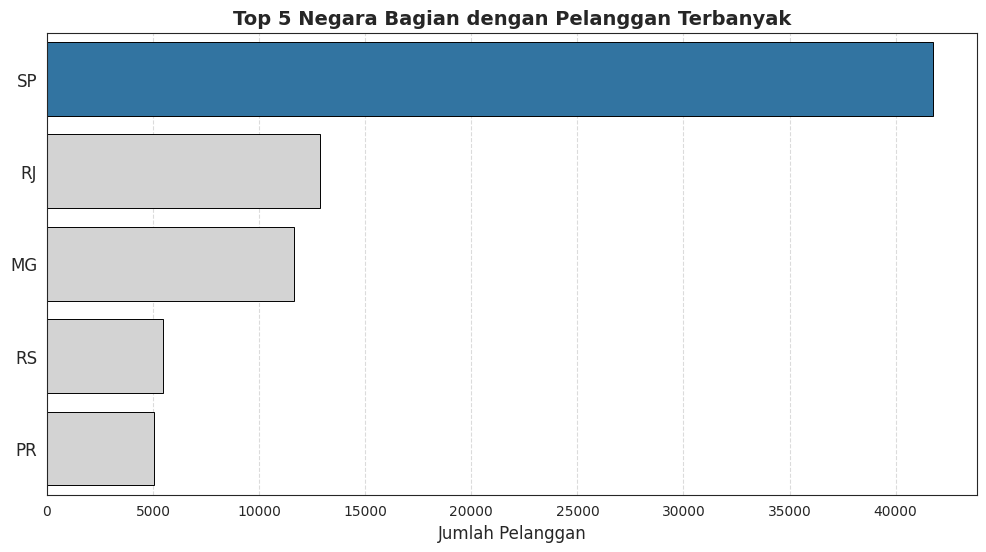

In [89]:
sns.set_style("white")
plt.figure(figsize=(12, 6))

colors_ = ["#1f77b4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]
avg_top5 = bystate_df['customer_count'].head(5).mean()

sns.barplot(
    x="customer_count",
    y="customer_state",
    data=bystate_df.head(5),
    palette=colors_,
    hue="customer_state",
    legend=False,
    edgecolor='black',
    linewidth=0.7
)

plt.title("Top 5 Negara Bagian dengan Pelanggan Terbanyak", loc="center", fontsize=14, fontweight='bold')
plt.ylabel(None)
plt.xlabel("Jumlah Pelanggan", fontsize=12)
plt.tick_params(axis='y', labelsize=12)


plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Pertanyaan 2:

Bagaimana proporsi produk di dalam katalog jika dikelompokkan berdasarkan kategori beratnya (Ringan <1kg, Sedang 1-5kg, Berat >5kg), dan kelompok mana yang paling dominan untuk bahan negosiasi tarif flat dengan mitra logistik pengiriman tahun ini?

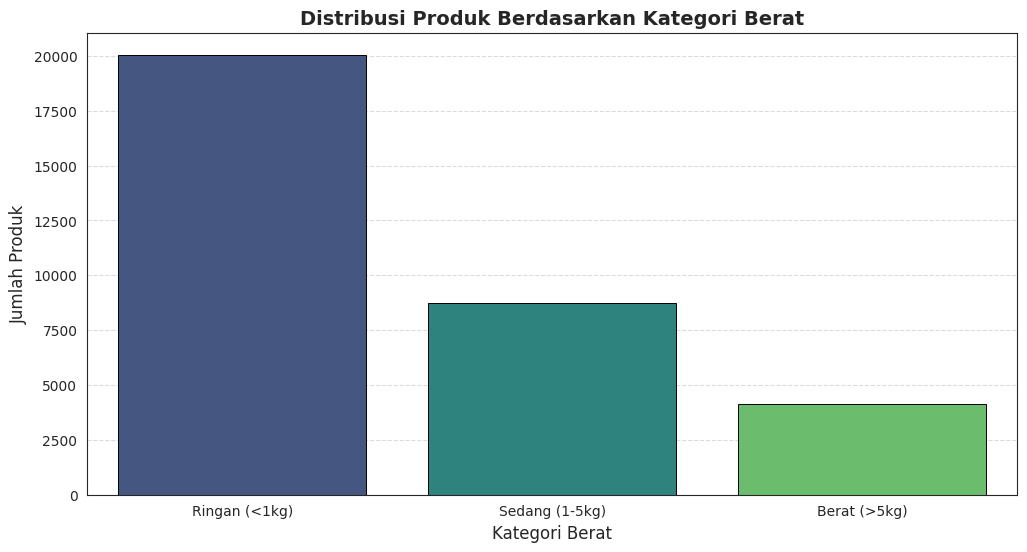

In [90]:
sns.set_style("white")
plt.figure(figsize=(12, 6))

avg_product = weight_dist_df['product_count'].mean()

sns.barplot(
    x="weight_category",
    y="product_count",
    data=weight_dist_df,
    palette="viridis",
    hue="weight_category",
    legend=False,
    edgecolor='black',
    linewidth=0.7
)

plt.title("Distribusi Produk Berdasarkan Kategori Berat", loc="center", fontsize=14, fontweight='bold')
plt.ylabel("Jumlah Produk", fontsize=12)
plt.xlabel("Kategori Berat", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Insight:**
- **Visualisasi 1:** Grafik *bar* memperlihatkan kesenjangan yang sangat ekstrem antara SP (São Paulo) dengan 4 negara bagian Top 5 lainnya. Bar untuk wilayah SP jauh melampaui garis batas rata-rata Top 5, menjadikannya target paling mutlak dan potensial untuk kampanye pemasaran lokal.

- **Visualisasi 2:** Grafik distribusi berat produk menegaskan bahwa proporsi produk ringan secara visual sangat mendominasi. Kategori sedang (1-5kg) menempati urutan kedua, dan produk berbobot berat (>5kg) adalah yang paling sedikit ketersediaannya.

## Analisis Lanjutan (Opsional)

*Catatan: Penerapan Analisis Lanjutan berupa teknik **Clustering (Binning / Manual Grouping)** telah diimplementasikan pada tahap EDA dan Visualisasi Pertanyaan 2, yaitu dengan mengelompokkan `product_weight_g` ke dalam 3 kategori ('Ringan', 'Sedang', 'Berat').*

Terima Kasih ^_^

## Conclusion & Recommendation

**Conclusion pertanyaan 1:**

Berdasarkan analisis visualisasi geografis, negara bagian SP (São Paulo) adalah wilayah dengan jumlah pelanggan yang mendominasi dengan perbedaan yang sangat signifikan dibandingkan wilayah lain, disusul oleh RJ (Rio de Janeiro) dan MG (Minas Gerais).

**Conclusion pertanyaan 2:**

Berdasarkan penerapan teknik clustering (binning), mayoritas besar produk di dalam katalog masuk dalam kategori Ringan (<1kg) berjumlah sekitar lebih dari 20.000 produk, yang berarti jenis produk yang dijual didominasi oleh barang-barang kecil.

**Rekomendasi Action Item:**
- Marketing: Tim pemasaran sebaiknya mengalokasikan minimal 50% dari anggaran pemasaran hyperlocal mereka pada kampanye yang terfokus di São Paulo (SP) karena probabilitas Return on Investment (ROI) akan jauh lebih tinggi mengingat ini adalah market utama.

- Logistics: Karena sebagian besar katalog adalah barang berukuran ringan (di bawah 1kg), tim Business Development (BD) bisa merancang kontrak negosiasi biaya pengiriman flat-rate khusus untuk paket kecil dengan pihak ekspedisi untuk menekan biaya shipping ke pengguna akhir.